# 2023 Kahramanmaraş M7.8

On February 6, 2023, a M7.8 earthquake struck the East Anatolian Fault zone,
causing over 50,000 fatalities across southern Turkey and Syria.

## 1. Setup

In [2]:
import h5py
import os, json, shutil, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import xml.etree.ElementTree as ET

EVENT = 'us6000jllz'
os.environ['EVENT'] = EVENT

REPO      = Path('/workspaces/shakemap-gf-workshop')
EVENT_CFG = REPO / 'data/event_configs' / EVENT
EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'

In [3]:
def check_event_inputs():
    print('Current event inputs:')
    for f in ['event.xml', 'rupture.json', 'stationlist.json',
              'instrumented_dat.json', 'dyfi_dat.json', 'sites.csv']:
        p = EVENT_DIR / f
        print(f'  {f}: {"✓" if p.exists() else "—"}')

def get_shakemap_stats(gridxml_path):
    tree = ET.parse(gridxml_path)
    root = tree.getroot()
    ns = {'sm': 'http://earthquake.usgs.gov/eqcenter/shakemap'}
    fields = root.findall('sm:grid_field', ns)
    field_names = [f.get('name') for f in fields]
    mmi_idx = field_names.index('MMI')
    spec = root.find('sm:grid_specification', ns)
    dx = float(spec.get('nominal_lon_spacing'))
    dy = float(spec.get('nominal_lat_spacing'))
    cell_area = dx * 111 * dy * 111 * np.cos(np.radians(37))
    data_text = root.find('sm:grid_data', ns).text.strip()
    mmi_vals = [float(line.split()[mmi_idx]) for line in data_text.split('\n') if line.strip()]
    mmi = np.array(mmi_vals)
    return {
        'Max MMI': f'{mmi.max():.1f}',
        'Area MMI≥VII (km²)': f'{(mmi >= 7).sum() * cell_area:,.0f}',
        'Area MMI≥VIII (km²)': f'{(mmi >= 8).sum() * cell_area:,.0f}',
        'Area MMI≥IX (km²)': f'{(mmi >= 9).sum() * cell_area:,.0f}',
    }

def get_residuals_from_hdf(products_path):
    hdf_path = Path(products_path) / 'shake_result.hdf'
    print(f'Checking: {hdf_path}, exists: {hdf_path.exists()}')
    if not hdf_path.exists():
        return None, None
    with h5py.File(hdf_path) as f:
        if 'stations_dict' not in f['dictionaries']:
            return None, None
        sl = json.loads(f['dictionaries']['stations_dict'][()])
    seismic = [f for f in sl['features'] 
               if f['properties'].get('station_type') == 'seismic']
    print(f'Seismic stations: {len(seismic)}')
    obs, pred = [], []
    for feat in seismic:
        props = feat['properties']
        intensity = props.get('intensity')
        pred_mmi = next((p['value'] for p in props.get('predictions', [])
                        if p['name'] == 'mmi'), None)
        if intensity is not None and pred_mmi is not None:
            try:
                obs.append(float(intensity))
                pred.append(float(pred_mmi))
            except:
                pass
    return np.array(obs), np.array(pred)

## 2. Stage the event

In [7]:
%%bash
export EVENT=us6000jllz
sm_create -f $EVENT

Wrote 4 files to /home/vscode/shakemap_profiles/default/data/us6000jllz/current:
	dyfi_dat.json
	event.xml
	instrumented_dat.json
	rupture.json


In [8]:
shutil.copy(EVENT_CFG / 'event.xml',    EVENT_DIR / 'event.xml')
shutil.copy(EVENT_CFG / 'rupture.json', EVENT_DIR / 'rupture.json')
shutil.copy(EVENT_CFG / 'model.conf',   EVENT_DIR / 'model.conf')
for f in ['stationlist.json', 'instrumented_dat.json', 'dyfi_dat.json']:
    p = EVENT_DIR / f
    if p.exists():
        p.unlink()
        print(f'Removed {f}')
import subprocess
subprocess.run(['shake', EVENT, 'select'], capture_output=True)
print('select done')
check_event_inputs()

Removed instrumented_dat.json
Removed dyfi_dat.json


select done
Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: —


## 3. Step 2: Grid mode with finite fault

Run ShakeMap using the finite fault rupture geometry but no station observations.

In [9]:
check_event_inputs()

Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: —


In [10]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid FF no stations' model contour mapping gridxml

INFO -- 2026-08-24 21:09:19 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:09:19 -- shake.main -- Finished running command assemble: Elapsed 0.04 secs
INFO -- 2026-08-24 21:09:19 -- shake.main -- Running command model
INFO -- 2026-08-24 21:09:19 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:09:19 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:09:19 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 21:09:19 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-24 21:09:19 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-24 21:09:25 -- shake.main -- Finished running command model: Elapsed 6.55 secs
INFO -- 2026-08-24 21:09:25 -- shake.main -- Running command contour
INFO -- 2026-08-24 21:09:27 -- shake.main --

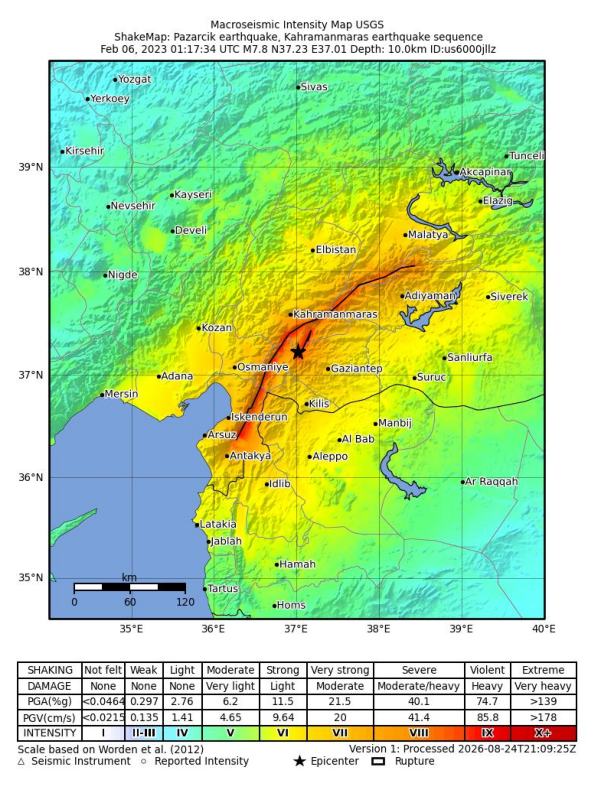

In [11]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step2_FF_grid.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step2_grid.xml')
step2_products = Path.home() / 'step2_products'
if step2_products.exists(): shutil.rmtree(step2_products)
shutil.copytree(PRODUCTS, step2_products)
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(PRODUCTS / 'intensity.jpg'))
plt.axis('off'); plt.tight_layout(); plt.show()

## 4. Step 3: Grid mode with point source

Remove rupture.json so ShakeMap uses a point source.

In [12]:
rupture = EVENT_DIR / 'rupture.json'
rupture_bak = EVENT_DIR / 'rupture.json.bak'
if rupture.exists():
    rupture.rename(rupture_bak)
    print('rupture.json moved — point source mode')
elif rupture_bak.exists():
    print('Already in point source mode')
check_event_inputs()

rupture.json moved — point source mode
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: —


In [13]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid point source' model contour mapping gridxml

INFO -- 2026-08-24 21:10:46 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:10:46 -- shake.main -- Finished running command assemble: Elapsed 0.04 secs
INFO -- 2026-08-24 21:10:46 -- shake.main -- Running command model
INFO -- 2026-08-24 21:10:46 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:10:46 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:10:46 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 21:10:46 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-24 21:10:46 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)


INFO -- 2026-08-24 21:10:51 -- shake.main -- Finished running command model: Elapsed 4.42 secs
INFO -- 2026-08-24 21:10:51 -- shake.main -- Running command contour
INFO -- 2026-08-24 21:10:52 -- shake.main -- Finished running command contour: Elapsed 1.46 secs
INFO -- 2026-08-24 21:10:52 -- shake.main -- Running command mapping
INFO -- 2026-08-24 21:11:15 -- shake.main -- Finished running command mapping: Elapsed 22.36 secs
INFO -- 2026-08-24 21:11:15 -- shake.main -- Running command gridxml
INFO -- 2026-08-24 21:11:16 -- shake.main -- Finished running command gridxml: Elapsed 0.95 secs
INFO -- 2026-08-24 21:11:16 -- shake.main -- shake finished with event us6000jllz


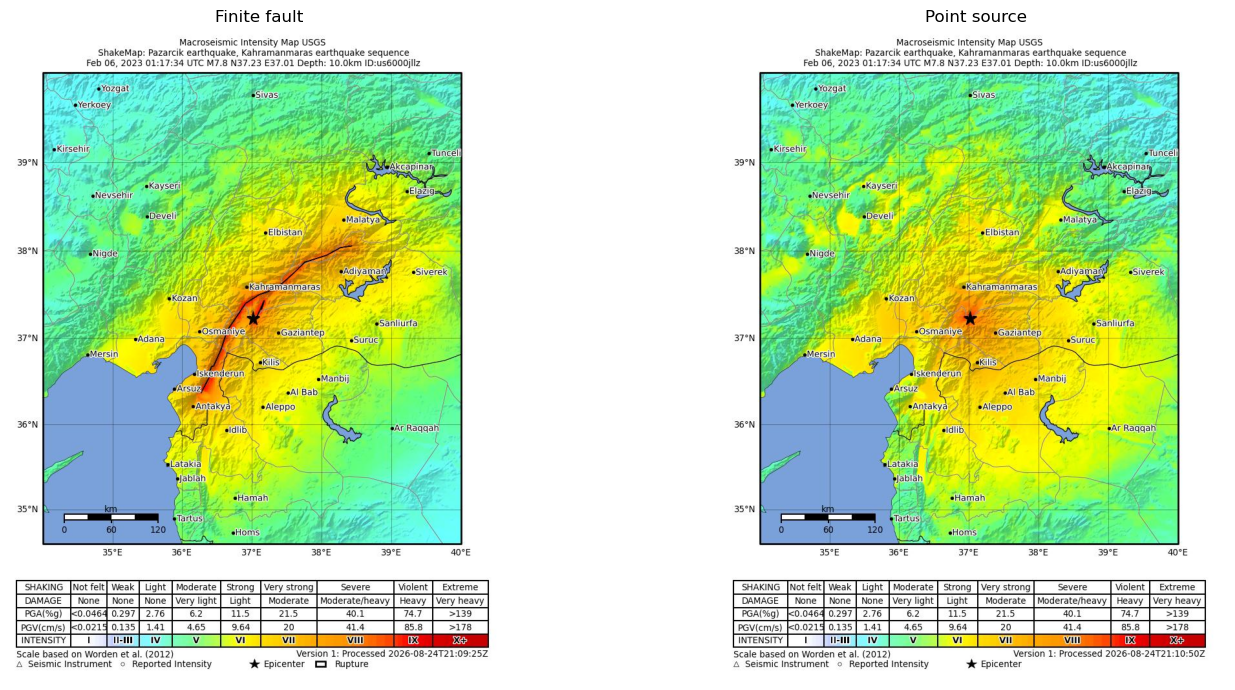

In [14]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step3_pointsource_grid.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step3_grid.xml')
step3_products = Path.home() / 'step3_products'
if step3_products.exists(): shutil.rmtree(step3_products)
shutil.copytree(PRODUCTS, step3_products)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, path, title in [
    (axes[0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault'),
    (axes[1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=12); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Step 1: Points mode — predict shaking at station locations

Restore the finite fault and run ShakeMap in points mode, predicting shaking
at the locations of the 262 seismic stations.

In [15]:
if rupture_bak.exists():
    rupture_bak.rename(EVENT_DIR / 'rupture.json')
    print('rupture.json restored')
with open(EVENT_CFG / 'stationlist.json') as f:
    stations = json.load(f)
rows = []
for feat in stations['features']:
    props = feat['properties']
    if props.get('network', '').upper() == 'DYFI':
        continue
    lon, lat = feat['geometry']['coordinates'][:2]
    network = props.get('network', 'XX')
    code_str = props.get('code', f'STA{len(rows):04d}')
    station_id = f'{network}.{code_str}' if '.' not in code_str else code_str
    rows.append({'id': station_id, 'lat': lat, 'lon': lon,
                 'vs30': props.get('vs30', 760.0) or 760.0})
sites_df = pd.DataFrame(rows)
sites_csv = EVENT_DIR / 'sites.csv'
sites_df.to_csv(sites_csv, index=False)
print(f'Wrote {len(rows)} seismic station locations to sites.csv')
print(sites_df['id'].head(3))
check_event_inputs()

rupture.json restored
Wrote 262 seismic station locations to sites.csv
0    KO.ARPRA
1     KO.CMRD
2     KO.KHMN
Name: id, dtype: str
Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


In [16]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -p ~/shakemap_profiles/default/data/$EVENT/current/sites.csv \
  -c 'points mode FF' model

INFO -- 2026-08-24 21:11:55 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:11:55 -- shake.main -- Finished running command assemble: Elapsed 0.04 secs
INFO -- 2026-08-24 21:11:55 -- shake.main -- Running command model
INFO -- 2026-08-24 21:11:55 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:11:55 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:11:57 -- shake.main -- Finished running command model: Elapsed 2.03 secs
INFO -- 2026-08-24 21:11:57 -- shake.main -- shake finished with event us6000jllz


In [17]:
%%bash
export EVENT=us6000jllz
shake $EVENT makecsv -g

INFO -- 2026-08-24 21:12:06 -- shake.main -- Running command makecsv
INFO -- 2026-08-24 21:12:06 -- shake.main -- Finished running command makecsv: Elapsed 0.08 secs
INFO -- 2026-08-24 21:12:06 -- shake.main -- shake finished with event us6000jllz


In [18]:
synthetic_files = glob.glob(str(PRODUCTS / '*points*.json'))
print('Generated files:', synthetic_files)

Generated files: ['/home/vscode/shakemap_profiles/default/data/us6000jllz/current/products/us6000jllz_points_GREATER_OF_TWO_HORIZONTAL.json']


## 6. Step 4: Grid mode — point source + FF-predicted stations

Remove the rupture and use the synthetic station data from the points mode run.

In [19]:
rupture = EVENT_DIR / 'rupture.json'
rupture_bak = EVENT_DIR / 'rupture.json.bak'
if rupture.exists():
    rupture.rename(rupture_bak)
    print('rupture.json moved — point source mode')
if synthetic_files:
    shutil.copy(synthetic_files[0], EVENT_DIR / 'stationlist.json')
    print(f'Copied {Path(synthetic_files[0]).name} as stationlist.json')
check_event_inputs()

rupture.json moved — point source mode
Copied us6000jllz_points_GREATER_OF_TWO_HORIZONTAL.json as stationlist.json
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: ✓
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


In [20]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid PS + FF stations' model contour mapping gridxml

INFO -- 2026-08-24 21:12:32 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:12:32 -- shake.main -- Finished running command assemble: Elapsed 0.09 secs
INFO -- 2026-08-24 21:12:32 -- shake.main -- Running command model
INFO -- 2026-08-24 21:12:32 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:12:32 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:12:33 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 21:12:33 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-24 21:12:33 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-24 21:12:46 -- shake.main -- Finished running command model: Elapsed 13.60 secs
INFO -- 2026-08-24 21:12:46 -- shake.main -- Running command contour
INFO -- 2026-08-24 21:12:48 -- shake.main -

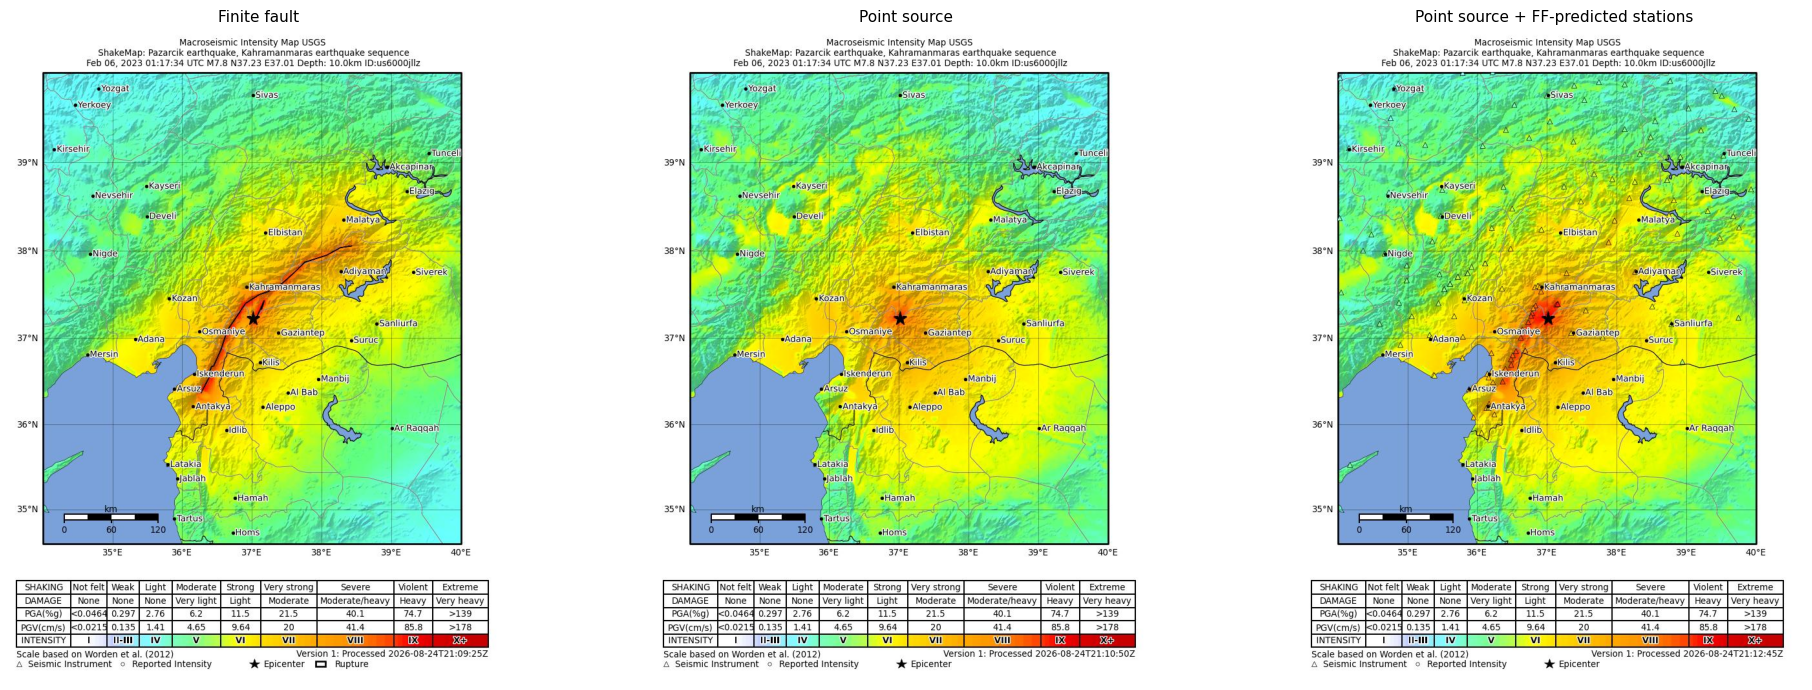

In [21]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step4_ps_ffstations.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step4_grid.xml')
step4_products = Path.home() / 'step4_products'
if step4_products.exists(): shutil.rmtree(step4_products)
shutil.copytree(PRODUCTS, step4_products)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, path, title in [
    (axes[0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault'),
    (axes[1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source'),
    (axes[2], Path.home() / 'step4_ps_ffstations.jpg',   'Point source + FF-predicted stations'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Step 5: Grid mode — point source + real observations

Use the actual 262 station observations.

In [22]:
for f in ['stationlist.json']:
    p = EVENT_DIR / f
    if p.exists(): p.unlink()
shutil.copy(EVENT_CFG / 'stationlist.json', EVENT_DIR / 'stationlist.json')
print('Real stationlist.json copied')
check_event_inputs()

Real stationlist.json copied
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: ✓
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


In [23]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid FF + real stations' model contour mapping gridxml

INFO -- 2026-08-24 21:14:12 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:14:12 -- shake.main -- Finished running command assemble: Elapsed 0.26 secs
INFO -- 2026-08-24 21:14:12 -- shake.main -- Running command model
INFO -- 2026-08-24 21:14:12 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:14:12 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:14:12 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 21:14:12 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-24 21:14:12 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-24 21:14:35 -- shake.main -- Finished running command model: Elapsed 23.40 secs
INFO -- 2026-08-24 21:14:35 -- shake.main -- Running command contour
INFO -- 2026-08-24 21:14:37 -- shake.main -

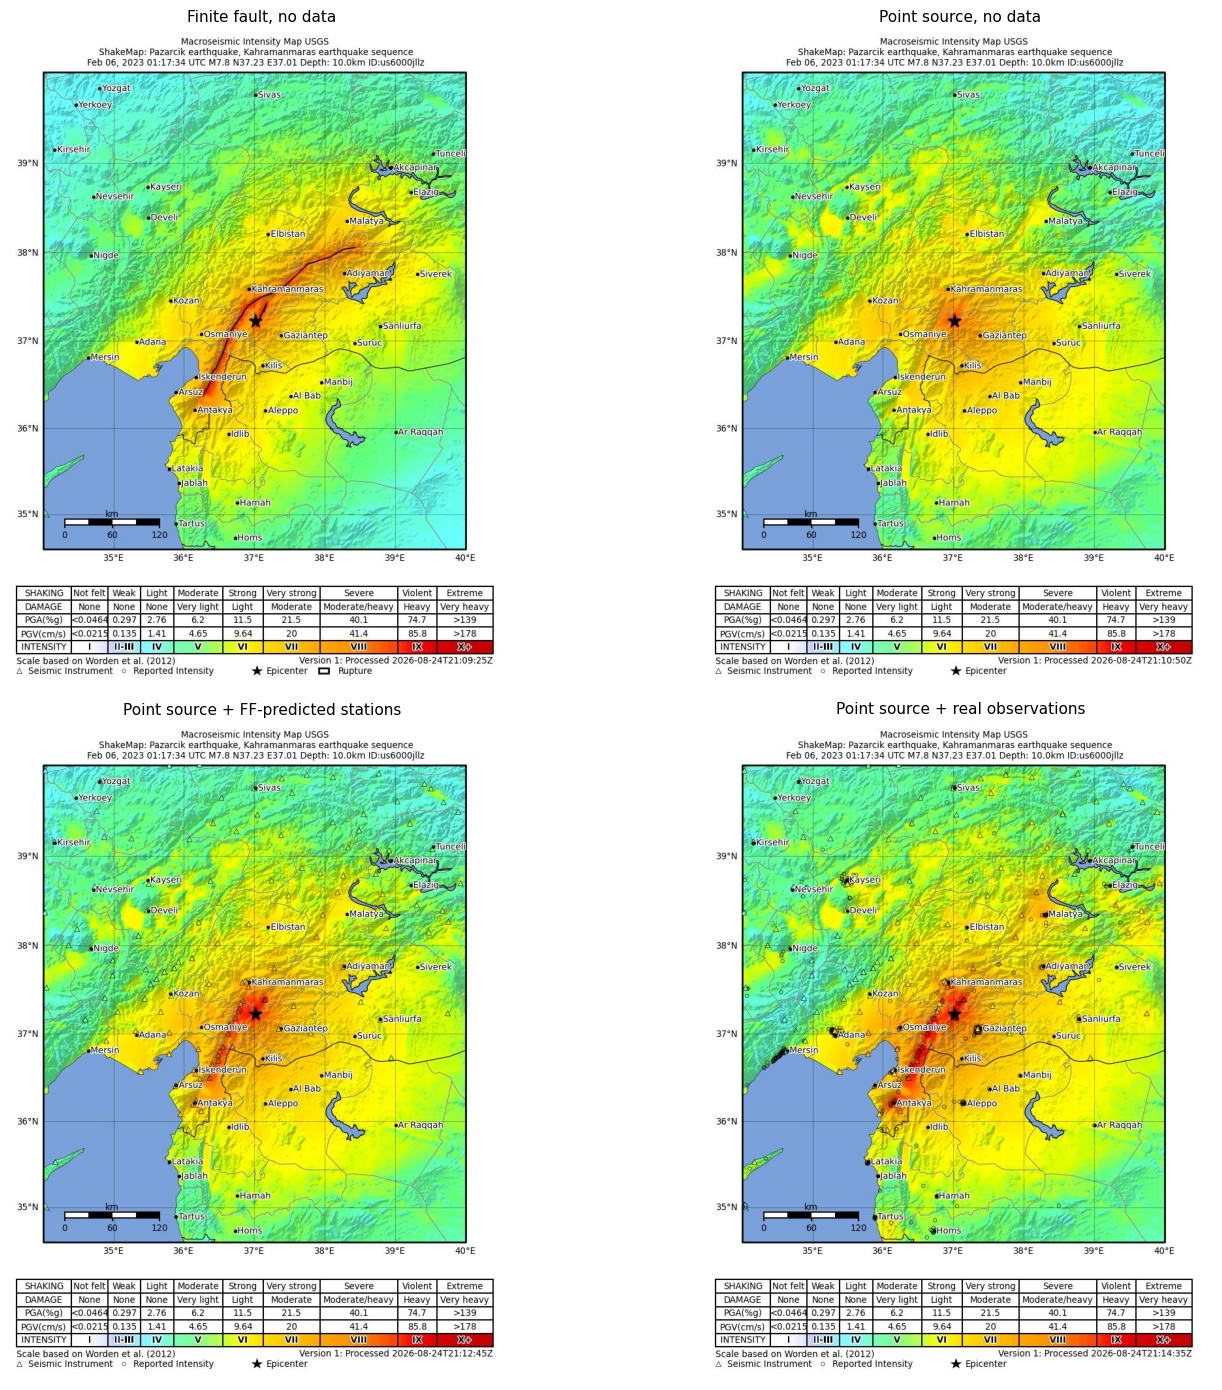

In [25]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step5_real_stations.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step5_grid.xml')
step5_products = Path.home() / 'step5_products'
if step5_products.exists(): shutil.rmtree(step5_products)
shutil.copytree(PRODUCTS, step5_products)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, path, title in [
    (axes[0,0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault, no data'),
    (axes[0,1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source, no data'),
    (axes[1,0], Path.home() / 'step4_ps_ffstations.jpg',   'Point source + FF-predicted stations'),
    (axes[1,1], Path.home() / 'step5_real_stations.jpg',   'Point source + real observations'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

## 8. Shaking statistics comparison

In [26]:
stats = {}
for label, grid_path in [
    ('Step 2: FF, no data',          Path.home() / 'step2_grid.xml'),
    ('Step 3: Point source, no data', Path.home() / 'step3_grid.xml'),
    ('Step 4: PS + FF stations',      Path.home() / 'step4_grid.xml'),
    ('Step 5: PS + real stations',    Path.home() / 'step5_grid.xml'),
]:
    if grid_path.exists():
        stats[label] = get_shakemap_stats(grid_path)
pd.DataFrame(stats).T

,Max MMI,Area MMI≥VII (km²),Area MMI≥VIII (km²),Area MMI≥IX (km²)
"Step 2: FF, no data",9.0,"16,320","3,787",4
"Step 3: Point source, no data",8.6,"9,651",769,0
Step 4: PS + FF stations,9.1,"16,708","2,758",44
Step 5: PS + real stations,9.4,"23,105","5,120",344


## 9. Observed vs predicted MMI

Checking: /home/vscode/step4_products/shake_result.hdf, exists: True
Seismic stations: 188
Checking: /home/vscode/step5_products/shake_result.hdf, exists: True
Seismic stations: 188


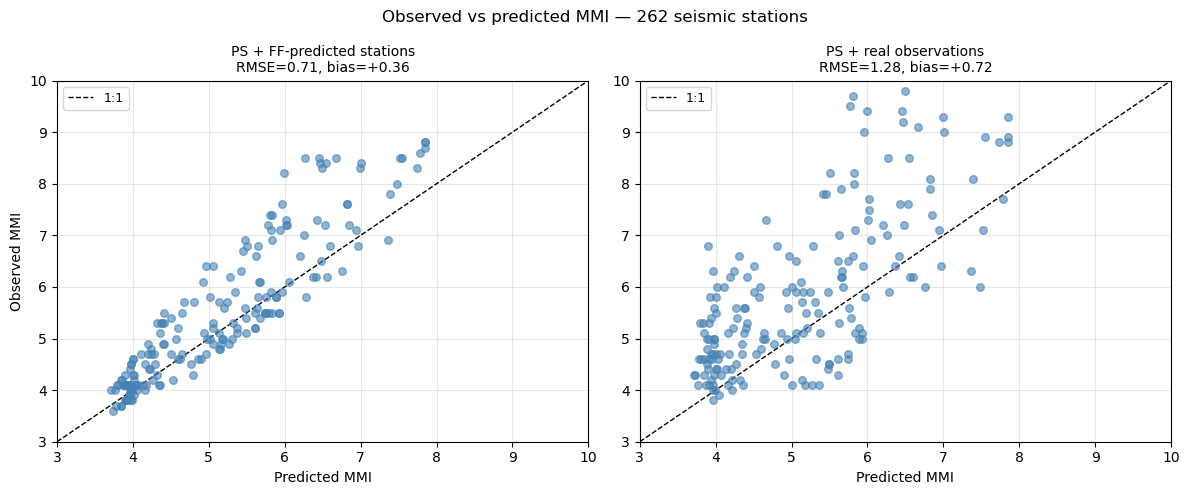

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lim = [3, 10]
step_products = [
    (Path.home() / 'step4_products', 'PS + FF-predicted stations'),
    (Path.home() / 'step5_products', 'PS + real observations'),
]
for ax, (prod_path, label) in zip(axes, step_products):
    obs, pred = get_residuals_from_hdf(prod_path)
    if obs is None or len(obs) == 0:
        ax.text(0.5, 0.5, 'No station\nresiduals', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_title(label, fontsize=10)
    else:
        residuals = obs - pred
        rmse = np.sqrt((residuals**2).mean())
        bias = residuals.mean()
        ax.scatter(pred, obs, alpha=0.6, s=30, color='steelblue', zorder=3)
        ax.plot(lim, lim, 'k--', linewidth=1, label='1:1')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('Predicted MMI', fontsize=10)
        ax.set_title(f'{label}\nRMSE={rmse:.2f}, bias={bias:+.2f}', fontsize=10)
        ax.grid(alpha=0.3); ax.legend(fontsize=9)
axes[0].set_ylabel('Observed MMI', fontsize=10)
plt.suptitle('Observed vs predicted MMI — 262 seismic stations', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Discussion

- How does the finite fault change the spatial pattern of shaking?
  Where does the elongation along the EAF make the biggest difference?
- Does the FF-predicted station data improve the point source?
  What does the RMSE tell us?
- Where do real observations change the ShakeMap most?

---
## 11. Exercise: What if only part of the fault ruptured?

Modify `LAT_THRESHOLD` to control which portion ruptures.

In [28]:
import copy
with open(EVENT_CFG / 'rupture.json') as f:
    rupture_full = json.load(f)
coords = rupture_full['features'][0]['geometry']['coordinates']
print(f'Full rupture: {len(coords)} polygons')
for i, poly in enumerate(coords):
    pts = poly[0]
    top = [p for p in pts if p[2] == 0.0]
    if top:
        lats = [p[1] for p in top]; lons = [p[0] for p in top]
        print(f'  Polygon {i+1}: lat {min(lats):.2f}–{max(lats):.2f}, lon {min(lons):.2f}–{max(lons):.2f}')

Full rupture: 1 polygons


In [29]:
import copy, json

with open(EVENT_CFG / 'rupture.json') as f:
    rupture_full = json.load(f)

ring = rupture_full['features'][0]['geometry']['coordinates'][0][0]
top_edge = [p for p in ring if p[2] == 1.0][:-1]  # exclude closing point
bot_edge = [p for p in ring if p[2] == 16.0]

# Keep points up to lat 37
top_trunc = [p for p in top_edge if p[1] <= 37.]
bot_trunc = [p for p in bot_edge if p[1] <= 37.]

print('Top truncated:', [round(p[1],2) for p in top_trunc])
print('Bot truncated:', [round(p[1],2) for p in bot_trunc])

new_ring = top_trunc + list(reversed(bot_trunc)) + [top_trunc[0]]
print('Ring points:', len(new_ring))
print('Closes correctly:', new_ring[0] == new_ring[-1])

rupture_partial = copy.deepcopy(rupture_full)
rupture_partial['features'][0]['geometry']['coordinates'] = [[new_ring]]

with open(EVENT_DIR / 'rupture.json', 'w') as f:
    json.dump(rupture_partial, f)
print('Written')

Top truncated: [36.37, 36.55, 36.61, 36.67, 36.68, 36.87]
Bot truncated: [36.87, 36.68, 36.67, 36.61, 36.55, 36.37]
Ring points: 13
Closes correctly: True
Written


In [33]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'partial rupture' model contour mapping gridxml

INFO -- 2026-08-24 21:21:07 -- shake.main -- Running command assemble
INFO -- 2026-08-24 21:21:07 -- shake.main -- Finished running command assemble: Elapsed 0.07 secs
INFO -- 2026-08-24 21:21:07 -- shake.main -- Running command model
INFO -- 2026-08-24 21:21:07 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:21:07 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 21:21:07 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 21:21:07 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-24 21:21:07 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-24 21:21:11 -- shake.main -- Finished running command model: Elapsed 4.31 secs
INFO -- 2026-08-24 21:21:11 -- shake.main -- Running command contour
INFO -- 2026-08-24 21:21:12 -- shake.main --

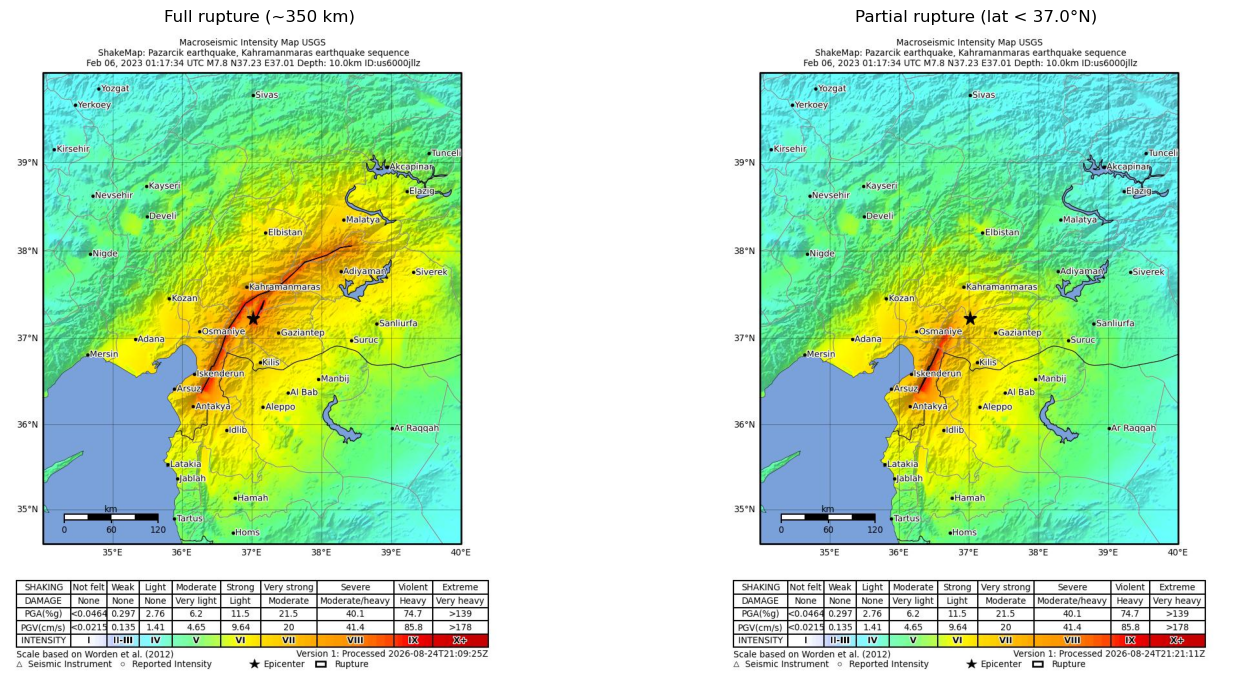

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, path, title in [
    (axes[0], Path.home() / 'step2_FF_grid.jpg', 'Full rupture (~350 km)'),
    (axes[1], PRODUCTS / 'intensity.jpg',         f'Partial rupture (lat < {37.0}°N)'),
]:
    ax.imshow(mpimg.imread(str(path))); ax.set_title(title, fontsize=12); ax.axis('off')
plt.tight_layout(); plt.show()

In [100]:
shutil.copy(EVENT_CFG / 'rupture.json', EVENT_DIR / 'rupture.json')
print('Full rupture.json restored')

Full rupture.json restored


**Discussion:**
- Which cities lose significant shaking when only part of the fault ruptures?